In [41]:
import pandas as pd
import numpy as np
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split

import matplotlib.pyplot as plt
import seaborn as sns

# The model
from sklearn.linear_model import LinearRegression

# Evaluation metrics
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

In [3]:
data = fetch_california_housing(as_frame=True)
df = data.frame
df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [4]:
df.info()
# no null value in columns

<class 'pandas.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   MedInc       20640 non-null  float64
 1   HouseAge     20640 non-null  float64
 2   AveRooms     20640 non-null  float64
 3   AveBedrms    20640 non-null  float64
 4   Population   20640 non-null  float64
 5   AveOccup     20640 non-null  float64
 6   Latitude     20640 non-null  float64
 7   Longitude    20640 non-null  float64
 8   MedHouseVal  20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB


## Checking outliers before modelling

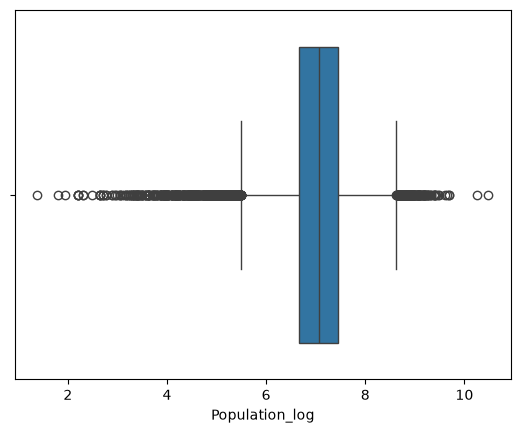

In [5]:
# columns_to_check = ['MedInc', 'HouseAge', 'AveRooms','AveBedrms','Population','AveOccup']
# columns_to_check = ['Population']

# Plotting them side-by-side
# sns.boxplot(data=df[columns_to_check])
# plt.show()

df['Population_log'] = np.log1p(df['Population'])
sns.boxplot(x=df['Population_log'])
plt.show()

In [6]:
print(df['Population'].describe())

count    20640.000000
mean      1425.476744
std       1132.462122
min          3.000000
25%        787.000000
50%       1166.000000
75%       1725.000000
max      35682.000000
Name: Population, dtype: float64


In [7]:
# Dropping very small population households
df = df[df['Population'] >= 50]

In [8]:
print(df['AveOccup'].describe())

count    20536.000000
mean         3.071548
std         10.411438
min          0.970588
25%          2.432108
50%          2.819632
75%          3.281612
max       1243.333333
Name: AveOccup, dtype: float64


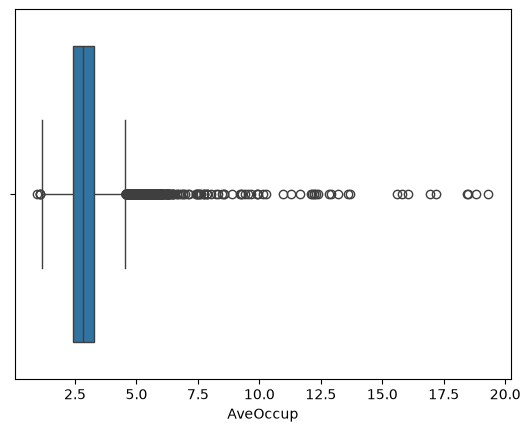

In [10]:
# check occupation per house by plot
sns.boxplot(x=df['AveOccup'])
plt.show()

In [9]:
# print(df.nsmallest(10, 'Population'))
# df.nlargest(10,'AveOccup')

# Dropping Occupation number > 20 per house rows #10 rows only
df = df[df['AveOccup'] <= 20]

## Checking HouseAge column for odd outliers

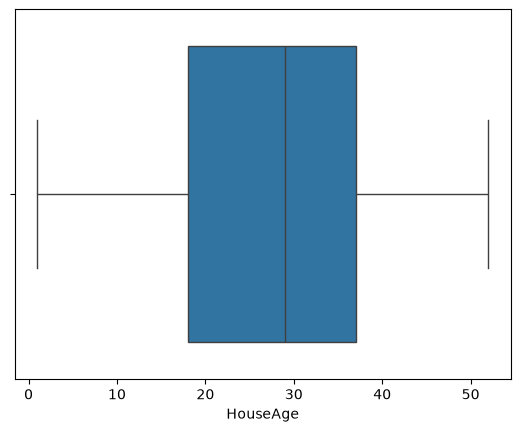

In [11]:
sns.boxplot(x=df['HouseAge'])
plt.show()
# looks pretty normal

In [12]:
df[['MedInc','AveRooms','AveBedrms','MedHouseVal']].describe()

,MedInc,AveRooms,AveBedrms,MedHouseVal
count,20526.000000,20526.000000,20526.000000,20526.000000
mean,3.870436,5.402379,1.090482,2.068809
std,1.889870,2.012817,0.344874,1.152683
min,0.499900,0.888889,0.444444,0.149990
25%,2.566325,4.441055,1.006332,1.198250
50%,3.536000,5.227887,1.048771,1.798000
75%,4.742600,6.048469,1.099081,2.647000
max,15.000100,62.422222,14.111111,5.000010


In [13]:
# print((df['MedHouseVal'] >= 5).sum())
df['MedHouseVal'].describe()

count    20526.000000
mean         2.068809
std          1.152683
min          0.149990
25%          1.198250
50%          1.798000
75%          2.647000
max          5.000010
Name: MedHouseVal, dtype: float64

In [14]:
# filter out rooms > 20
df = df[df['AveRooms'] <= 20]

In [15]:
# nearly a thousand rows for 500k and 1 dollar mark. suspicious , not a real value
df = df[df['MedHouseVal'] != 5.00001]

# Data is all Clean. Modelling and predicting phase

In [16]:
# features
X = df[['MedInc','HouseAge','AveRooms','AveBedrms','Population','AveOccup']]
# target
y = df['MedHouseVal']

In [17]:
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.2,shuffle=True,random_state=42)

model = LinearRegression()
model.fit(X_train,y_train)

y_pred = model.predict(X_test)

r2_score(y_test,y_pred)

0.5564613780868908

### Lets add coordinates if it will improve the result

In [18]:
X2 = df[['MedInc','HouseAge','AveRooms','AveBedrms','Population','AveOccup','Latitude','Longitude']]
X2_train, X2_test, y2_train, y2_test = train_test_split(X2, y, test_size=0.2, shuffle=True, random_state=42)

model2 = LinearRegression()
model2.fit(X2_train, y2_train)
y2_pred = model2.predict(X2_test)

r2_score(y2_test, y2_pred)

0.6302897045094471

In [19]:
coefs = pd.Series(model.coef_, index=X.columns)
print(coefs.sort_values(ascending=False))

AveBedrms     1.157002
MedInc        0.575229
HouseAge      0.015514
Population    0.000050
AveOccup     -0.211954
AveRooms     -0.274670
dtype: float64


In [20]:
print(df[['AveRooms','AveBedrms']].corr())

           AveRooms  AveBedrms
AveRooms   1.000000   0.519119
AveBedrms  0.519119   1.000000


In [21]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

vif_data = pd.DataFrame()
vif_data['feature'] = X.columns
vif_data['VIF'] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
print(vif_data)

      feature        VIF
0      MedInc  12.095440
1    HouseAge   5.813475
2    AveRooms  47.529435
3   AveBedrms  38.062902
4  Population   2.890564
5    AveOccup  10.842061


In [22]:
df['BedrmRatio'] = df['AveBedrms'] / df['AveRooms']
df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal,Population_log,BedrmRatio
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526,5.777652,0.146591
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585,7.784057,0.155797
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521,6.208590,0.129516
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413,6.326149,0.184458
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422,6.338594,0.172096


In [28]:
X3 = df[['MedInc','HouseAge','BedrmRatio','Population','AveOccup','Latitude','Longitude']]
X3_train, X3_test, y3_train, y3_test = train_test_split(X3, y, test_size=0.2, shuffle=True, random_state=42)

model3 = LinearRegression()
model3.fit(X3_train, y3_train)
y3_pred = model3.predict(X3_test)

r2_score(y3_test, y3_pred)

0.637004113579567

In [24]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
X_vif = df[['MedInc','HouseAge','BedrmRatio','Population','AveOccup']]
vif_data = pd.DataFrame()
vif_data['feature'] = X_vif.columns
vif_data['VIF'] = [variance_inflation_factor(X_vif.values, i) for i in range(X_vif.shape[1])]
print(vif_data)

      feature        VIF
0      MedInc   4.665123
1    HouseAge   6.438485
2  BedrmRatio  10.452258
3  Population   2.976137
4    AveOccup  11.130885


## Adding decision tree

In [36]:
from sklearn.tree import DecisionTreeClassifier

# creating is house expensive column
median_val = df['MedHouseVal'].median()
df['Expensive'] = (df['MedHouseVal'] > median_val).astype(int)

X_tree = df[['MedInc','HouseAge','AveRooms','AveBedrms','Population','AveOccup','Latitude','Longitude']]
y_tree = df['Expensive']

X_tree_train, X_tree_test, y_tree_train, y_tree_test = train_test_split(X_tree, y_tree, test_size=0.2, shuffle=True, random_state=42)

tree = DecisionTreeClassifier(max_depth=5, random_state=42)
tree.fit(X_tree_train,y_tree_train)

importance = pd.Series(tree.feature_importances_, index=X_tree.columns)
print(importance.sort_values(ascending=False))

MedInc        0.655163
AveOccup      0.121508
Longitude     0.085427
Latitude      0.071073
HouseAge      0.035444
AveRooms      0.030439
Population    0.000945
AveBedrms     0.000000
dtype: float64


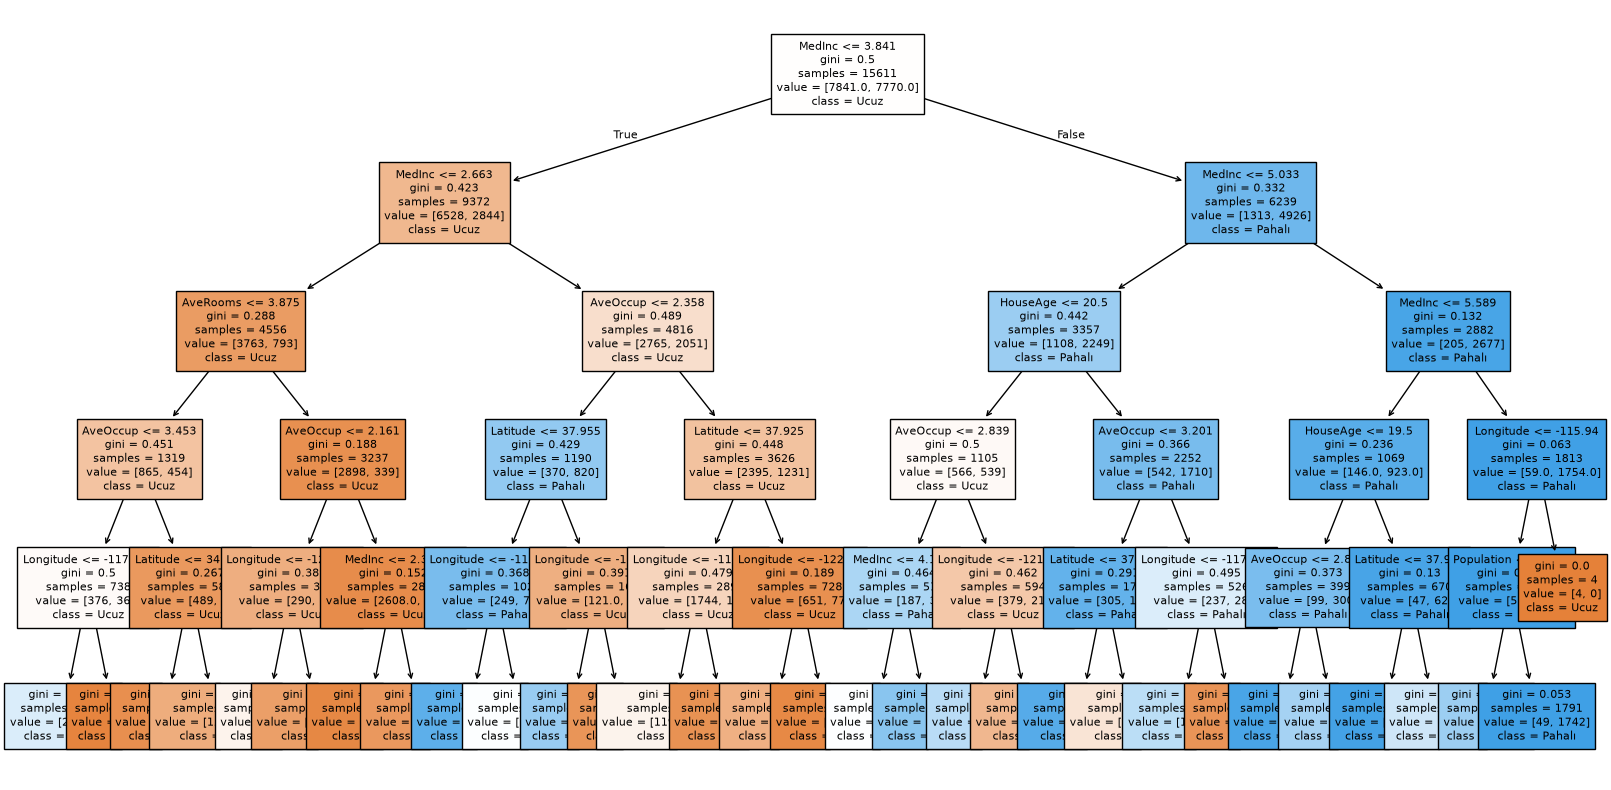

In [38]:
from sklearn.tree import plot_tree
plt.figure(figsize=(20,10))
plot_tree(tree, feature_names=X_tree.columns, class_names=['Ucuz','Pahalı'], filled=True, fontsize=8)
plt.show()

In [42]:
y_tree_pred = tree.predict(X_tree_test)

y_tree_proba = tree.predict_proba(X_tree_test)[:, 1]  # AUC için olasılık skorları

print("Accuracy:", accuracy_score(y_tree_test, y_tree_pred))
print("Precision:", precision_score(y_tree_test, y_tree_pred))
print("Recall:", recall_score(y_tree_test, y_tree_pred))
print("F1:", f1_score(y_tree_test, y_tree_pred))
print("AUC:", roc_auc_score(y_tree_test, y_tree_proba))

# Overfitting kontrolü için train skorunu da al
train_acc = accuracy_score(y_tree_train, tree.predict(X_train))
print("Train Accuracy:", train_acc)


Accuracy: 0.7786318216756342
Precision: 0.8075865860362836
Recall: 0.740796772566818
F1: 0.7727511835875854
AUC: 0.8741744936123719
Train Accuracy: 0.7893792838383191


## Random Forest

In [43]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=200,   # kaç tane ağaç kuracak
    max_depth=8,        # her ağacın maksimum derinliği (aynı Decision Tree'deki mantık)
    random_state=42
)
rf.fit(X_tree_train, y_tree_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",8
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap:

In [44]:
y_rf_pred = rf.predict(X_tree_test)
y_rf_proba = rf.predict_proba(X_tree_test)[:, 1]

In [50]:
print("Accuracy:", accuracy_score(y_tree_test, y_rf_pred))
print("Precision:", precision_score(y_tree_test, y_rf_pred))
print("Recall:", recall_score(y_tree_test, y_rf_pred))
print("F1:", f1_score(y_tree_test, y_rf_pred))
print("AUC:", roc_auc_score(y_tree_test, y_rf_proba))
print("Train Accuracy:", accuracy_score(y_tree_train, rf.predict(X_tree_train)))

Accuracy: 0.8657442992569818
Precision: 0.8739108149666838
Recall: 0.8598083711548159
F1: 0.8668022369089985
AUC: 0.9447393994789041
Train Accuracy: 0.8936006661969125


In [48]:
importance = pd.Series(rf.feature_importances_, index=X_tree.columns)
print(importance.sort_values(ascending=False))

MedInc        0.384597
Latitude      0.181690
Longitude     0.158508
AveOccup      0.123872
AveRooms      0.074995
HouseAge      0.032453
AveBedrms     0.028867
Population    0.015018
dtype: float64
